# Rep. 4. Checkpoint 2. Estrategias I

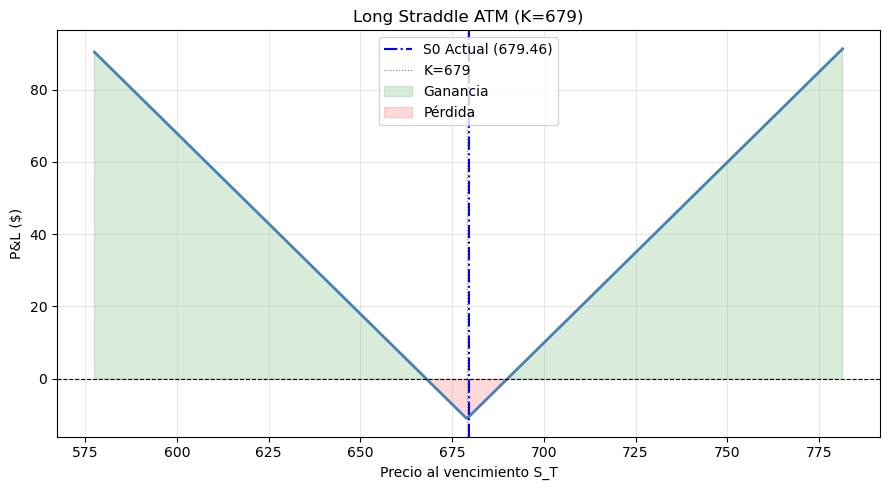

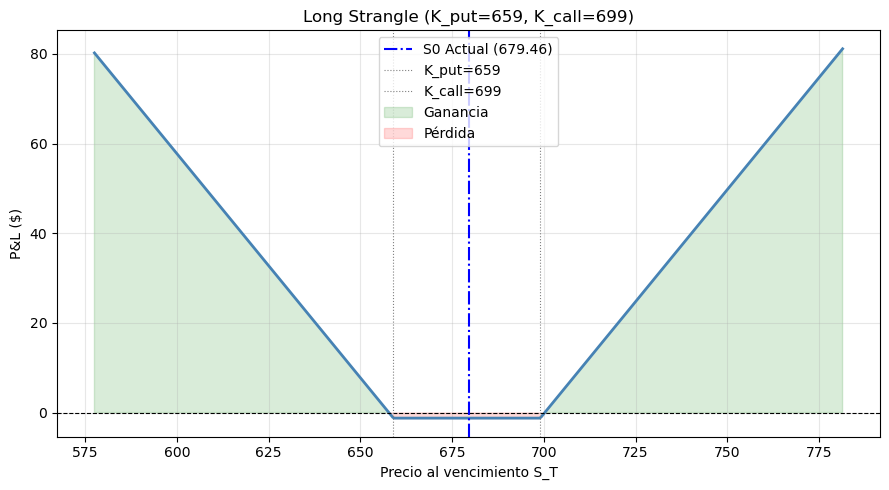

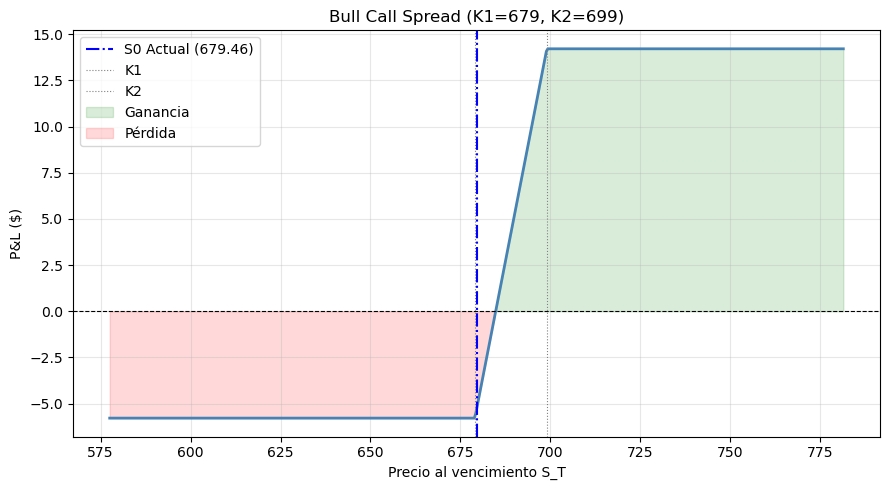

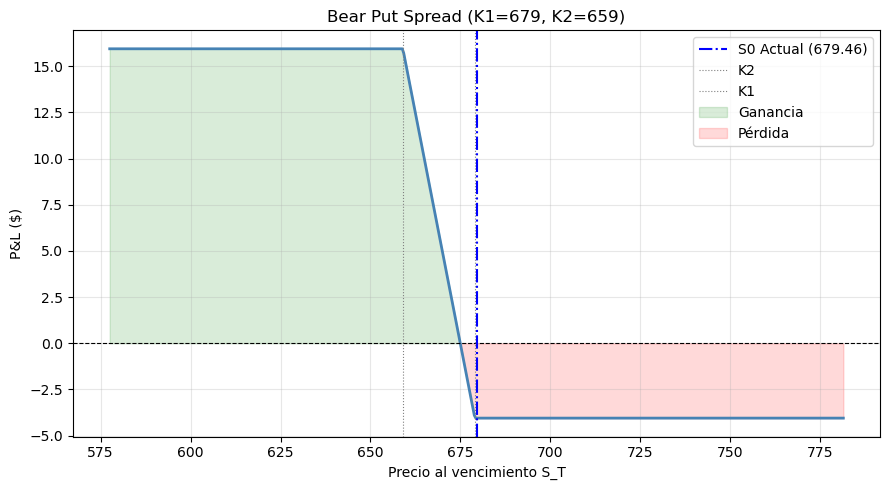

,Estrategia,Costo Neto,Max Ganancia,Max Pérdida,Break-Even
0,Long Straddle,11.080,Infinita,-11.080,667.92 / 690.08
1,Long Strangle,1.235,Infinita,-1.235,657.76 / 700.24
2,Bull Call Spread,5.790,14.21,-5.790,684.79
3,Bear Put Spread,4.055,15.945,-4.055,674.95


In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Funciones Base Corregidas ---
def payoff_estrategia(S_range, legs):
    total = np.zeros(len(S_range))
    for leg in legs:
        if leg['tipo'] == 'call':
            payoff = np.maximum(S_range - leg['K'], 0)
        else:
            payoff = np.maximum(leg['K'] - S_range, 0)
        pnl = leg['posicion'] * (payoff - leg['prima'])
        total += pnl
    return total

# Se agrega 'S0' a los parámetros para graficar la línea del precio actual
def graficar_estrategia(S_range, pnl, titulo, S0=None, K_lines=None):
    plt.figure(figsize=(9, 5))
    plt.plot(S_range, pnl, color='steelblue', linewidth=2)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    
    if S0 is not None:
        plt.axvline(S0, color='blue', linewidth=1.5, linestyle='-.', label=f'S0 Actual ({S0:.2f})')
        
    if K_lines:
        for k, label in K_lines:
            plt.axvline(k, color='gray', linewidth=0.8, linestyle=':', label=label)
            
    plt.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green', label='Ganancia')
    plt.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red', label='Pérdida')
    plt.xlabel('Precio al vencimiento S_T')
    plt.ylabel('P&L ($)')
    plt.title(titulo)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- 2. Extracción Dinámica de yfinance ---
spy = yf.Ticker("SPY")
S0 = spy.history(period="1d")['Close'].iloc[-1]
S_range = np.linspace(S0 * 0.85, S0 * 1.15, 500) # Rango de +-15% dinámico

try:
    options = spy.option_chain('2026-04-17')
    calls = options.calls
    puts = options.puts
    
    # Función auxiliar para obtener el precio mid más cercano a un strike
    def get_mid_price(df, strike):
        row = df.iloc[(df['strike'] - strike).abs().argsort()[:1]]
        return (row['bid'].values[0] + row['ask'].values[0]) / 2

    # Definir Strikes basados en S0 actual
    K_atm = round(S0) # Strike más cercano al dinero para Straddle
    K_call_otm = K_atm + 20 # Para Strangle y Bull Spread
    K_put_otm = K_atm - 20  # Para Strangle y Bear Spread

    # Extraer primas
    C_atm = get_mid_price(calls, K_atm)
    P_atm = get_mid_price(puts, K_atm)
    C_otm = get_mid_price(calls, K_call_otm)
    P_otm = get_mid_price(puts, K_put_otm)

    resultados = []

    # --- 3. Ejecución de Estrategias ---
    
    # A) Long Straddle
    legs_straddle = [
        {'tipo': 'call', 'K': K_atm, 'prima': C_atm, 'posicion': 1},
        {'tipo': 'put', 'K': K_atm, 'prima': P_atm, 'posicion': 1}
    ]
    pnl_straddle = payoff_estrategia(S_range, legs_straddle)
    graficar_estrategia(S_range, pnl_straddle, f'Long Straddle ATM (K={K_atm})', S0=S0, K_lines=[(K_atm, f'K={K_atm}')])
    resultados.append({'Estrategia': 'Long Straddle', 'Costo Neto': C_atm+P_atm, 'Max Ganancia': 'Infinita', 'Max Pérdida': -(C_atm+P_atm), 'Break-Even': f"{K_atm-(C_atm+P_atm):.2f} / {K_atm+(C_atm+P_atm):.2f}"})

    # B) Long Strangle
    legs_strangle = [
        {'tipo': 'call', 'K': K_call_otm, 'prima': C_otm, 'posicion': 1},
        {'tipo': 'put', 'K': K_put_otm, 'prima': P_otm, 'posicion': 1}
    ]
    pnl_strangle = payoff_estrategia(S_range, legs_strangle)
    graficar_estrategia(S_range, pnl_strangle, f'Long Strangle (K_put={K_put_otm}, K_call={K_call_otm})', S0=S0, K_lines=[(K_put_otm, f'K_put={K_put_otm}'), (K_call_otm, f'K_call={K_call_otm}')])
    resultados.append({'Estrategia': 'Long Strangle', 'Costo Neto': C_otm+P_otm, 'Max Ganancia': 'Infinita', 'Max Pérdida': -(C_otm+P_otm), 'Break-Even': f"{K_put_otm-(C_otm+P_otm):.2f} / {K_call_otm+(C_otm+P_otm):.2f}"})

    # C) Bull Call Spread
    legs_bull = [
        {'tipo': 'call', 'K': K_atm, 'prima': C_atm, 'posicion': 1},
        {'tipo': 'call', 'K': K_call_otm, 'prima': C_otm, 'posicion': -1}
    ]
    pnl_bull = payoff_estrategia(S_range, legs_bull)
    costo_bull = C_atm - C_otm
    graficar_estrategia(S_range, pnl_bull, f'Bull Call Spread (K1={K_atm}, K2={K_call_otm})', S0=S0, K_lines=[(K_atm, 'K1'), (K_call_otm, 'K2')])
    resultados.append({'Estrategia': 'Bull Call Spread', 'Costo Neto': costo_bull, 'Max Ganancia': (K_call_otm - K_atm) - costo_bull, 'Max Pérdida': -costo_bull, 'Break-Even': f"{K_atm + costo_bull:.2f}"})

    # D) Bear Put Spread
    legs_bear = [
        {'tipo': 'put', 'K': K_atm, 'prima': P_atm, 'posicion': 1},
        {'tipo': 'put', 'K': K_put_otm, 'prima': P_otm, 'posicion': -1}
    ]
    pnl_bear = payoff_estrategia(S_range, legs_bear)
    costo_bear = P_atm - P_otm
    graficar_estrategia(S_range, pnl_bear, f'Bear Put Spread (K1={K_atm}, K2={K_put_otm})', S0=S0, K_lines=[(K_put_otm, 'K2'), (K_atm, 'K1')])
    resultados.append({'Estrategia': 'Bear Put Spread', 'Costo Neto': costo_bear, 'Max Ganancia': (K_atm - K_put_otm) - costo_bear, 'Max Pérdida': -costo_bear, 'Break-Even': f"{K_atm - costo_bear:.2f}"})

    # --- 4. Tabla Resumen ---
    df_resumen = pd.DataFrame(resultados)
    display(df_resumen)

except Exception as e:
    print(f"Error al descargar opciones (probablemente mercado cerrado o fecha inválida): {e}")

**1. Con el S0 actual, ¿cuál de las cuatro estrategias está más cerca de su zona de máxima pérdida? ¿Qué te dice eso sobre la visión de mercado que expresa?**
El Long Straddle y el Long Strangle. Esto indica una visión de mercado de alta incertidumbre muy probablemente gracias a trump y cadavez que habla jajaja.

**2. Compara el costo total del long straddle vs. el long strangle que construiste. ¿Cuánto más barato es el strangle? ¿Cuánto más tiene que moverse SPY para que el strangle sea rentable comparado con el straddle?**
El Strangle es considerablemente más barato porque utiliza opciones OTM, es casi 10 dolares mas barato. Sin embargo, exige un movimiento direccional mayor de SPY para ser rentable, ya que el precio debe rebasar los strikes OTM y además recuperar la prima pagada, alejando los puntos de break-even comparado con el Straddle.

**3. Un long straddle gana si el mercado se mueve mucho. ¿Qué pasa si compras el straddle justo después de que la IV ya subió por anticipación de un evento (por ejemplo, el día antes de earnings o de una decisión de la Fed)? ¿Sigue siendo una buena estrategia? Justifica.**
Es una mala estrategia por el efecto el colapso de volatilidad. Tras el evento, la incertidumbre desaparece, la IV cae drásticamente y destruye el valor de ambas opciones (por su exposición a Vega positivo), generando pérdidas aunque el precio se mueva.

**4. El bull call spread limita la ganancia máxima comparado con un call simple. ¿Por qué alguien aceptaría ese límite voluntariamente? Da al menos dos razones.**
1) **Menor costo y riesgo:** La prima cobrada por vender la Call superior financia la Call comprada. 
2) **Mayor probabilidad de éxito:** Al ser más barato, el punto de equilibrio (break-even) es más bajo y fácil de alcanzar que en un Call simple.

**5. Si tienes un bull spread abierto y SPY supera K2 antes del vencimiento, ¿tiene sentido cerrar la posición o esperar al vencimiento? ¿Qué factores considerarías para decidir?**
Tiene sentido cerrar la posición para asegurar ganancias. Los factores a considerar son el riesgo de que el precio revierta por debajo de K2 y el costo de oportunidad de mantener capital bloqueado solo para exprimir un remanente mínimo de valor tiempo.

**6. ¿Cómo afecta un aumento de IV a un bull spread comparado con un long straddle? ¿Cuál de las dos posiciones es más sensible a cambios en volatilidad implícita y por qué?**
El Long Straddle es inmensamente más sensible y se beneficia de un alza en IV porque es "Vega positivo" puro (tienes dos opciones compradas). El Bull Spread es casi neutral a la IV; el aumento de valor en la Call comprada se cancela con el aumento de valor en la Call vendida.

**7. En términos de griegas (delta, gamma, vega, theta), ¿cuál es la diferencia principal entre comprar un call simple y comprar un bull call spread? ¿Qué griega cambia más drásticamente entre las dos estructuras?**
El Bull Call Spread reduce la exposición a todas las griegas, pero la que cambia más drásticamente es **Vega**. El Call simple tiene Vega positivo (alta exposición a la IV), mientras que en el spread, Vega se neutraliza casi a cero por la combinación de una posición larga y una corta.